In [1]:
import os
import sys
os.chdir("../")
sys.path.insert(0, os.path.abspath("."))
configs_file = "train_cvit"

In [2]:
# !unset LD_LIBRARY_PATH
# !unset CUDA_HOME
# !unset CUDA_PATH

In [3]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from ldc.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

In [4]:
# re_vals = [100, 200, 500, 1000, 2000]
# data_paths = [f"./data/ldc/flow_fields_Re{re_val}_N128.npz" for re_val in re_vals]
# # x = jnp.linspace(0, 1, 128)
# # y = jnp.linspace(0, 1, 128)
# # X, Y = jnp.meshgrid(x, y, indexing="xy")
# data_sample = jnp.load(data_paths[0])
# X = data_sample["X"]
# Y = data_sample["Y"]

# fig, axes = plt.subplots(
#     nrows=2,
#     ncols=len(re_vals),
#     figsize=(1.25 * len(re_vals), 1.25*2),
#     constrained_layout=True,
# )
# for idx, (re_val, data_path) in enumerate(zip(re_vals, data_paths)):
#     data = jnp.load(data_path)
#     u = data["u"]
#     v = data["v"]
#     speed = jnp.sqrt(u**2 + v**2)
#     ax = axes[0, idx]
#     ax.contourf(
#         X, Y, speed,
#         levels=50,
#         cmap="RdBu_r",
#         vmin=0,
#         vmax=1.0,
#     )
#     ax.set_axis_off()
#     ax.text(
#         0.5, 1.05,
#         f"Re = {re_val}",
#         fontsize=8,
#         ha="center",
#         va="bottom",
#         transform=ax.transAxes,
#     )
#     ax.set_aspect("equal")
    
#     ax = axes[1, idx]
#     psi = data["psi"]
#     ax.contourf(
#         X, Y, psi,
#         levels=50,
#         cmap="RdBu_r",
#     )
#     ax.set_axis_off()
#     ax.set_aspect("equal")
    
#     if idx == 0:
#         axes[0, idx].text(
#             -0.05, 0.5,
#             "Velocity Magnitude",
#             fontsize=7,
#             rotation=90,
#             ha="center",
#             va="center",
#             transform=axes[0, idx].transAxes,
#         )
#         axes[1, idx].text(
#             -0.05, 0.5,
#             "Stream Function",
#             fontsize=7,
#             rotation=90,
#             ha="center",
#             va="center",
#             transform=axes[1, idx].transAxes,
#         )

In [5]:
from ldc.simplified_cvit import CViT

key = jax.random.PRNGKey(0)
model_params = configs.model_params

# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/20260126-165653/model_epoch_8000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0126-renold100_2000/model_epoch_20000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0127-reynold50_1000-linearsampling/model_epoch_26000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0127-reynold50_1000-logspacesampling/model_epoch_30000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0127-reynold50_1000-schedual_free/model_epoch_20000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/SOTA-0205/model_epoch_33000.eqx"
# model_params.update({
#     "dec_depth": 2,
# })

weight = "/root/autodl-tmp/tf-logs/ldc/cvit/SOTA-0218-decdepth4/model_epoch_15000.eqx"
model_params.update({
    "dec_depth": 4,
})

model_skeleton = CViT(
    key,
    **model_params,
)
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [6]:
# Nx = configs.Nx
# Ny = configs.Ny
Nx = 256
Ny = 256
data = jnp.load(configs.data_dir + f"/ldc_solutions_Re50-1000_N{Nx}.npz")
X = data["X"]
Y = data["Y"]
coords = jnp.stack([
    X.reshape(-1),
    Y.reshape(-1)
], axis=-1)  # (Ny*Nx, 2)
target_reynold = data["Re"]
ref_data = data["data"]
target_reynold = target_reynold.reshape(-1, 1)  # (B, 1)

In [7]:

target_reynold_normed = configs.normalize_re(target_reynold)
sols = jax.vmap(
    model, in_axes=(0, None)
)(target_reynold_normed, coords)  # (B, Ny*Nx, 3)

B, _, C = sols.shape
H = Ny
W = Nx
sols = rearrange(sols, "B (H W) C -> B C H W", H=int(H), W=int(W))  # (B, 3, H, W)
sols = sols[:, :2, ...]
# mask 左上和右上角的奇点，把u, v, speed对应位置设为0
eps = 1e-2
mask = (X > 1 - eps) & (Y > 1 - eps) | (X < eps) & (Y > 1 - eps)
# sols = jnp.where(mask[None, None, :, :], 0.0, sols)
# ref_data = jnp.where(mask[None, None, :, :], 0.0, ref_data)
l2 = jnp.sqrt(jnp.mean((sols - ref_data)**2, axis=(-1, -2))) / jnp.sqrt(jnp.mean(ref_data**2, axis=(-1, -2)))
l2 = jnp.mean(l2)
print("L2 relative error:", l2)

L2 relative error: 0.06854373


Text(0.5, 0, 'Reynolds Number')

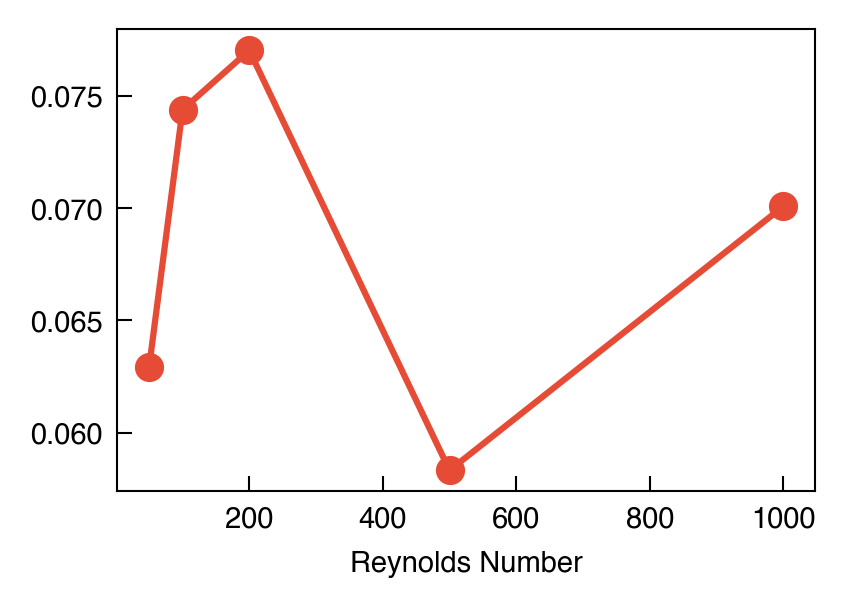

In [8]:
# Re-wise l2 error
l2_per_re = jnp.sqrt(jnp.mean((sols - ref_data)**2, axis=(-1, -2))) / jnp.sqrt(jnp.mean(ref_data**2, axis=(-1, -2)))
l2_per_re = jnp.mean(l2_per_re, axis=1)
fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(target_reynold[:, 0], l2_per_re, marker="o")
ax.set_xlabel("Reynolds Number")

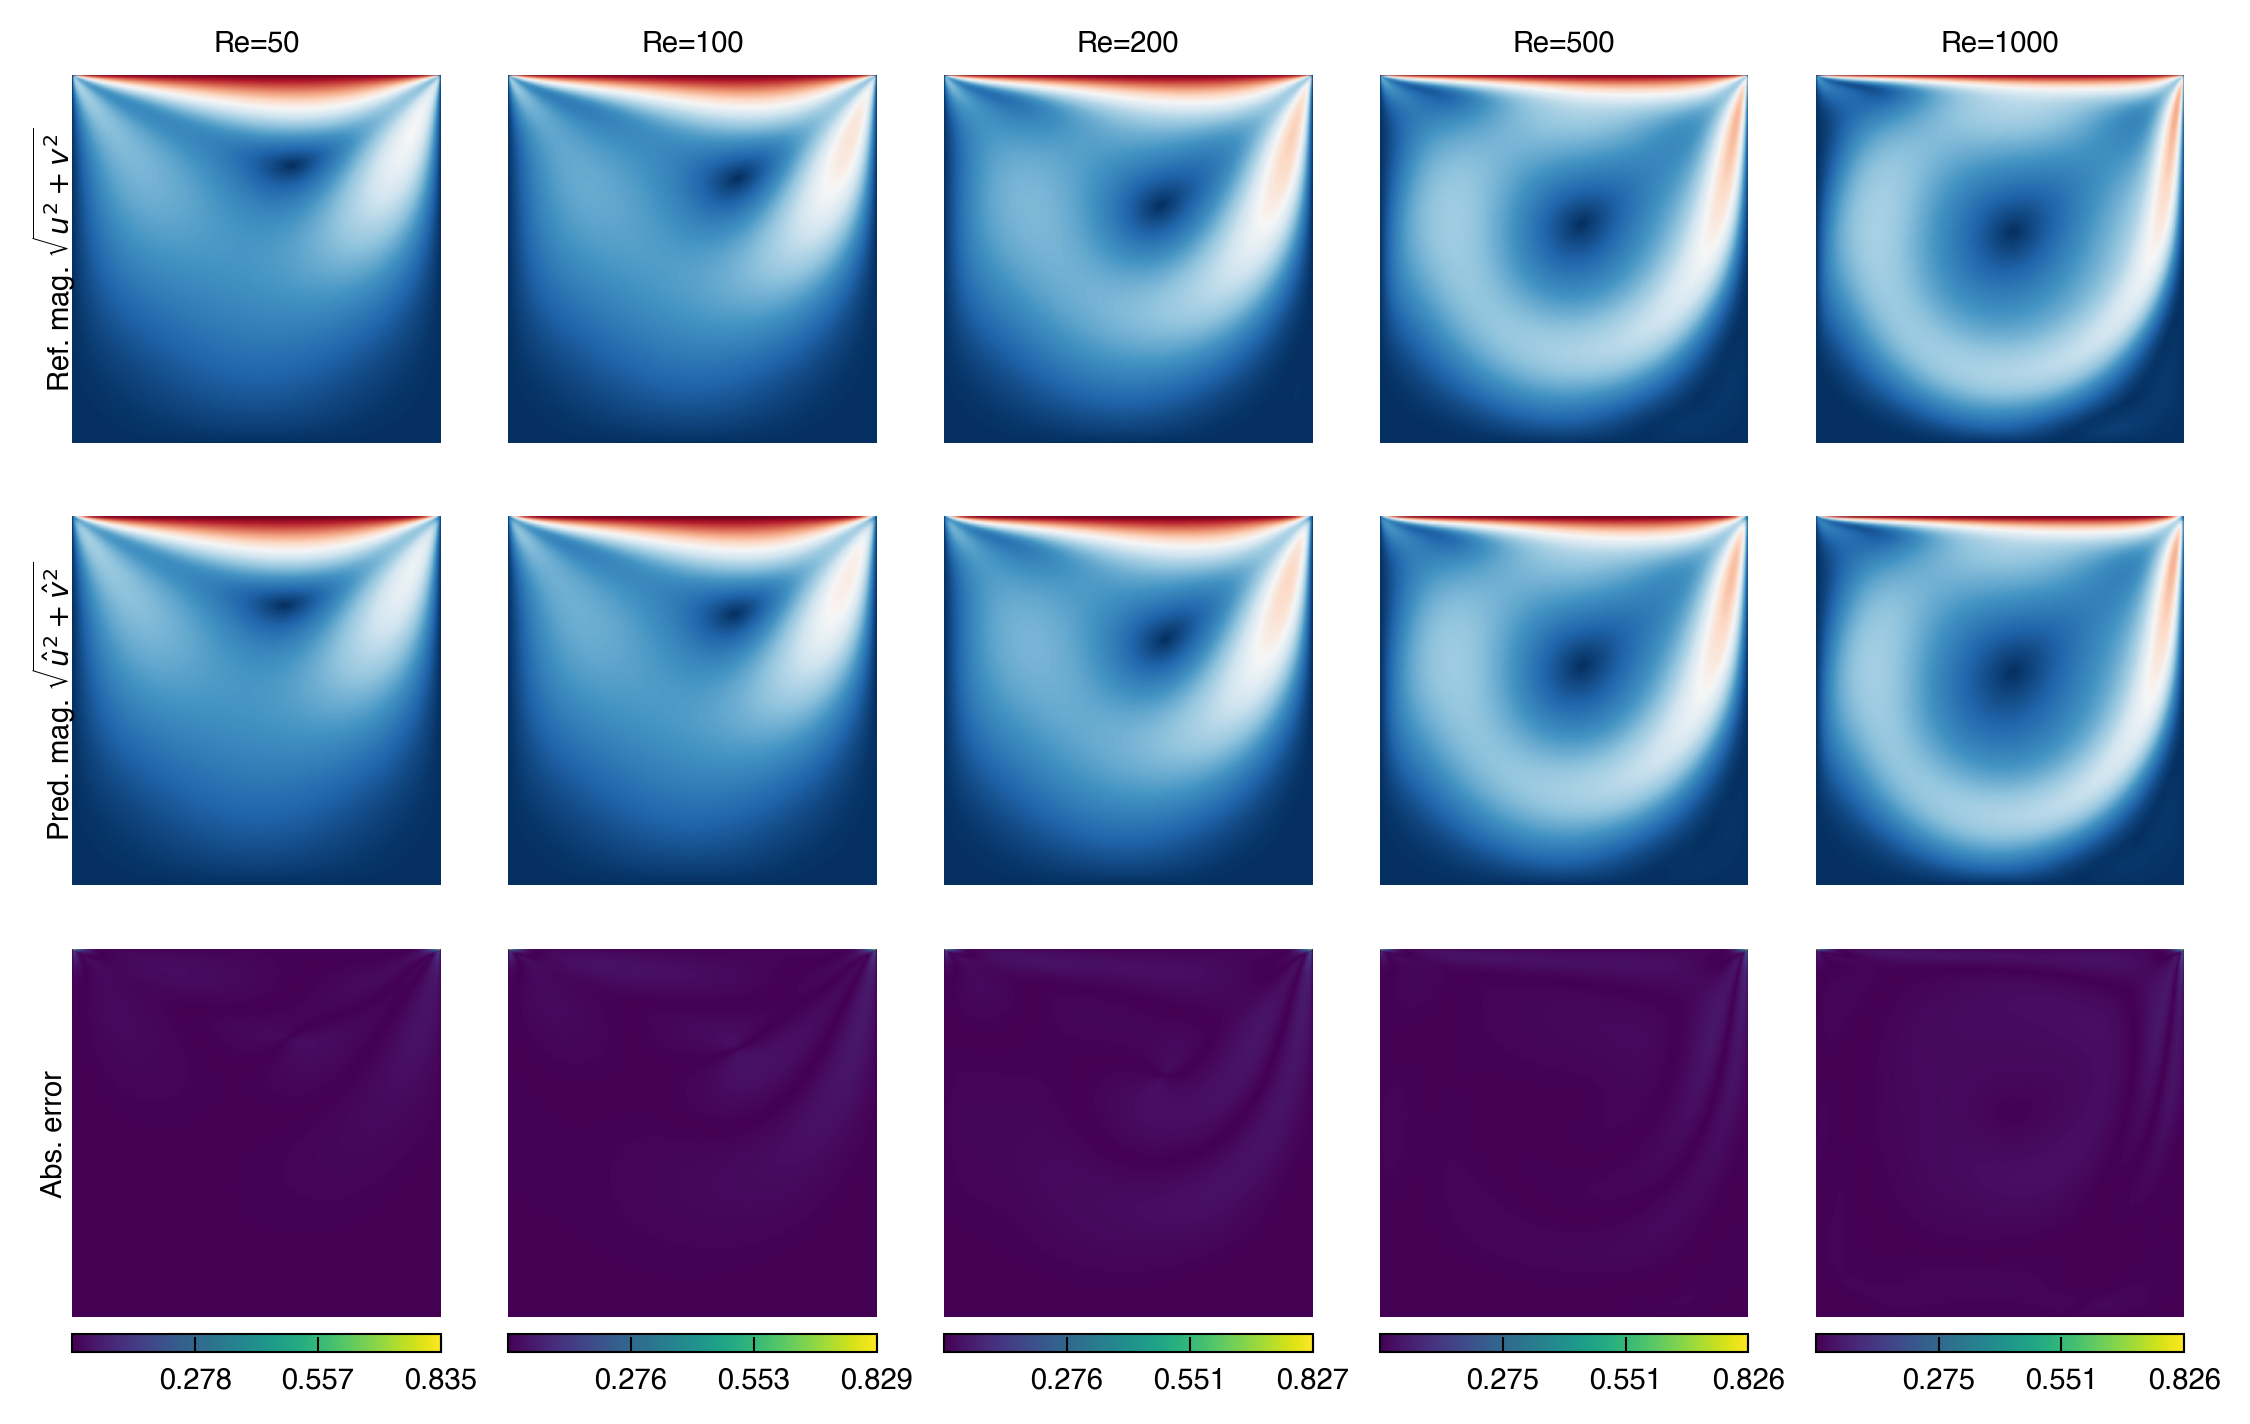

In [9]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=B,
    figsize=(1.5 * B, 4.8),
    subplot_kw={"aspect": "equal",},
)

for i, this_reynold in enumerate(target_reynold):
    ax = axes[0, i]
    ax.set_axis_off()

    ref_speed = jnp.sqrt(ref_data[i, 0, :, :]**2 + ref_data[i, 1, :, :]**2)
    ref_cont = ax.pcolormesh(
        X, Y, ref_speed, cmap="RdBu_r",
        vmin=0, vmax=1.0, shading="gouraud", rasterized=True
    )
    # fig.colorbar(ref_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
    #              format="%.2f", ticks=jnp.linspace(0, jnp.max(ref_speed), num=4)[1:])
    ax.text(
        0.5, 1.05, f"Re={int(this_reynold[0])}", 
        transform=ax.transAxes,
        ha="center", va="bottom",
    )
    
    ax = axes[1, i]
    ax.set_axis_off()
    speed = jnp.sqrt(sols[i, 0, :, :]**2 + sols[i, 1, :, :]**2)
    pred_cont = ax.pcolormesh(
        X, Y, speed, cmap="RdBu_r",
        vmin=0, vmax=1.0, shading="gouraud", rasterized=True
    )
    # fig.colorbar(pred_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
    #              format="%.2f", ticks=jnp.linspace(0, jnp.max(speed), num=4)[1:])
    
    ax = axes[2, i]
    ax.set_axis_off()
    diff = jnp.abs(ref_speed - speed)
    diff_cont = ax.pcolormesh(X, Y, diff, cmap="viridis", shading="gouraud", rasterized=True)
    colorbar = fig.colorbar(
        diff_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
        format="%.3f", ticks=jnp.linspace(0, jnp.max(diff),
                                          num=4)[1:]
    ) 
    
    if i == 0:
        axes[0, i].text(
            -0.05, 0.5, r"Ref. mag. $\sqrt{u^2 + v^2}$",
            transform=axes[0, i].transAxes,
            rotation=90, ha="center", va="center",
        )
        axes[1, i].text(
            -0.05, 0.5, r"Pred. mag. $\sqrt{\hat{u}^2 + \hat{v}^2}$",
            transform=axes[1, i].transAxes,
            rotation=90, ha="center", va="center",
        )
        axes[2, i].text(
            -0.05, 0.5, r"Abs. error",
            transform=axes[2, i].transAxes,
            rotation=90, ha="center", va="center",
        )
fig.tight_layout()
# fig.suptitle("Rel. L2 Error: %.2e" % l2, y=1.02)
fig.savefig("./figures/ldc_solution_field.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
fig.savefig("./figures/ldc_solution_field.pdf", dpi=300, bbox_inches="tight", pad_inches=0.03)

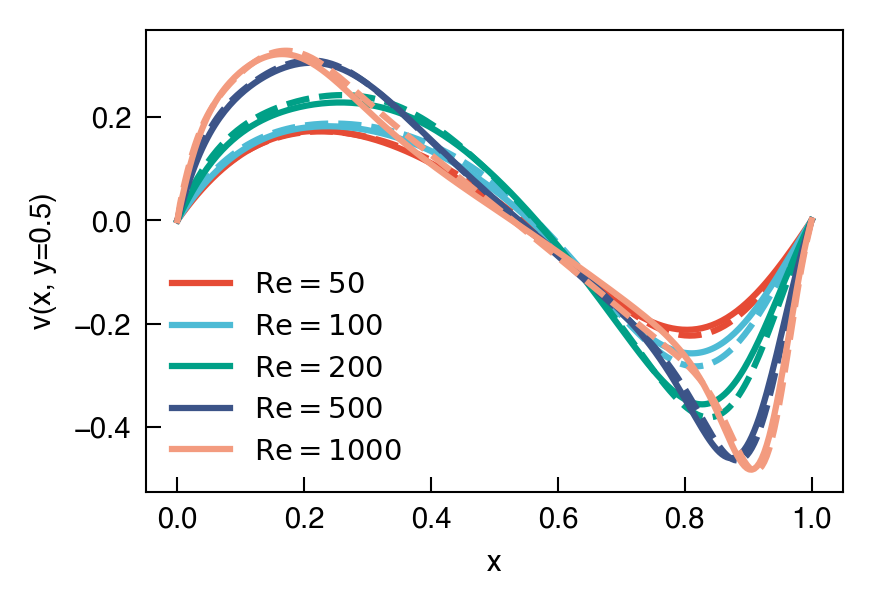

In [10]:
x = jnp.linspace(0, 1, Nx)
y = jnp.linspace(0, 1, Ny)
# 绘制 v 在 y=0.5 处的剖面图
y_index = Ny // 2  # y=0.5 对应的索引
fig, ax = plt.subplots(figsize=(3, 2))
for i, this_reynold in enumerate(target_reynold):

    plt.plot(
        x,
        ref_data[i, 1, y_index, :],
        # label=f"Ref. Re={int(this_reynold[0])}",
        linestyle="--",
        color=f"C{i}",
    )
    
    plt.plot(
        x,
        sols[i, 1, y_index, :],
        # label=f"Re={int(this_reynold[0])}",
        label=fr"$\mathrm{{Re}}={int(this_reynold[0])}$",
        linestyle="-",
        color=f"C{i}",
    )
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("v(x, y=0.5)")
fig.savefig("./figures/ldc_velocity_profile_v.png", dpi=300, bbox_inches="tight", pad_inches=0.0)
fig.savefig("./figures/ldc_velocity_profile_v.pdf", dpi=300, bbox_inches="tight", pad_inches=0.0)

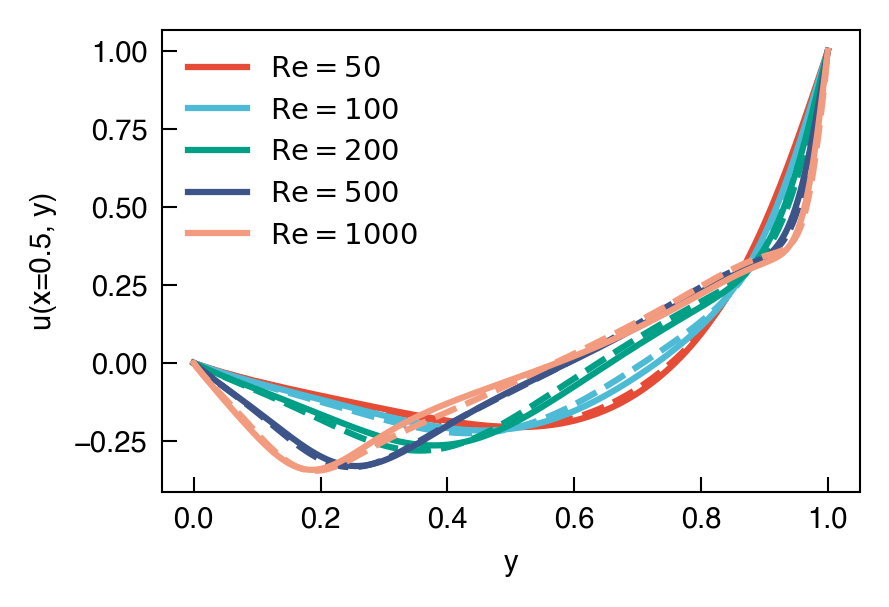

In [11]:
# 绘制 v 在 x=0.5 处的剖面图
x_index = Nx // 2  # x=0.5 对应的索引
# plt.figure(figsize=(3, 2))
fig, ax = plt.subplots(figsize=(3, 2))
for i, this_reynold in enumerate(target_reynold):

    ax.plot(
        y,
        ref_data[i, 0, :, x_index],
        # label=f"Ref. Re={int(this_reynold[0])}",
        linestyle="--",
        color=f"C{i}",
    )
    
    ax.plot(
        y,
        sols[i, 0, :, x_index],
        # label=f"Re={int(this_reynold[0])}",
        label=fr"$\mathrm{{Re}}={int(this_reynold[0])}$",
        linestyle="-",
        color=f"C{i}",
    )
ax.legend()
ax.set_xlabel("y")
ax.set_ylabel("u(x=0.5, y)")
fig.savefig("./figures/ldc_velocity_profile_u.png", dpi=300, bbox_inches="tight", pad_inches=0.0)
fig.savefig("./figures/ldc_velocity_profile_u.pdf", dpi=300, bbox_inches="tight", pad_inches=0.0)

In [12]:
epochs = jnp.arange(0, 15001, configs.save_every)

model_weight_template = "/root/autodl-tmp/tf-logs/ldc/cvit/SOTA-0218-decdepth4/model_epoch_{}.eqx"
error_log = []
# mask 左上和右上角的奇点，把u, v, speed对应位置设为0
eps = 1e-2
# mask = (X > 1 - eps) & (Y > eps) | (X < eps) & (Y > 1 - eps)
def fwd_fn(model, target_reynold_normed, coords):
    sols = jax.vmap(
        model, in_axes=(0, None)
    )(target_reynold_normed, coords)  # (B, Ny*Nx, 3)
    B, _, C = sols.shape
    H = Ny
    W = Nx
    sols = rearrange(sols, "B (H W) C -> B C H W", H=int(H), W=int(W))  # (B, 3, H, W)
    sols = sols[:, :2, ...]
    # sols = jnp.where(mask[None, None, :, :], 0.0, sols)
    return sols

for epoch in epochs:
    model = eqx.tree_deserialise_leaves(
        model_weight_template.format(int(epoch)), model_skeleton
    )
    sols = fwd_fn(model, target_reynold_normed, coords)
    l2 = jnp.sqrt(jnp.mean((sols - ref_data)**2, axis=(-1, -2))) / jnp.sqrt(jnp.mean(ref_data**2, axis=(-1, -2)))
    l2 = jnp.mean(l2)
    error_log.append(l2)
    print(f"Epoch {int(epoch)}: L2 relative error: {l2:.6f}")
error_log = jnp.array(error_log)

Epoch 0: L2 relative error: 1.042427
Epoch 1000: L2 relative error: 0.547694
Epoch 2000: L2 relative error: 0.228770
Epoch 3000: L2 relative error: 0.152718
Epoch 4000: L2 relative error: 0.122518
Epoch 5000: L2 relative error: 0.100753
Epoch 6000: L2 relative error: 0.086315
Epoch 7000: L2 relative error: 0.075883


Epoch 8000: L2 relative error: 0.072032
Epoch 9000: L2 relative error: 0.070507
Epoch 10000: L2 relative error: 0.070856
Epoch 11000: L2 relative error: 0.070843
Epoch 12000: L2 relative error: 0.069715
Epoch 13000: L2 relative error: 0.069148
Epoch 14000: L2 relative error: 0.068504
Epoch 15000: L2 relative error: 0.068544


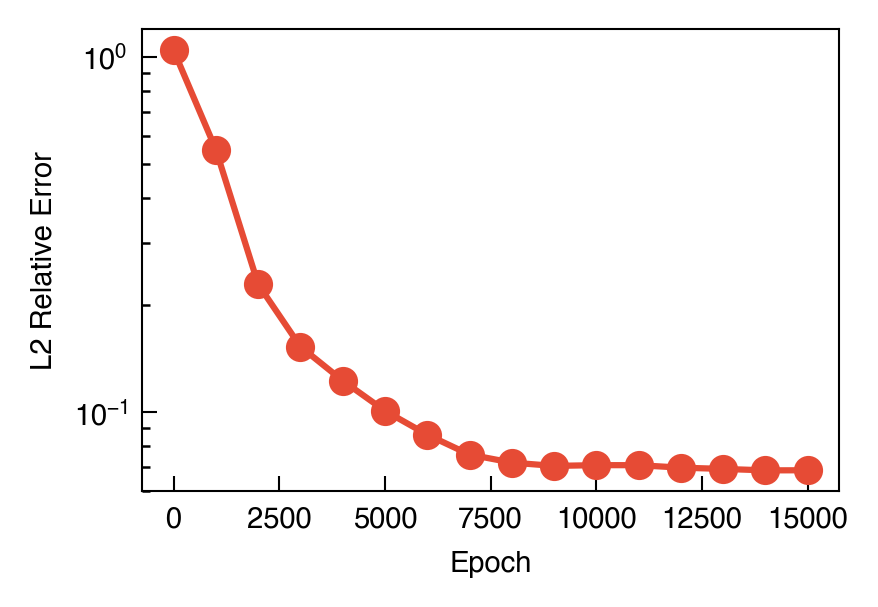

In [13]:
from models.utils import smooth_loss_log_gaussian

fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(epochs, error_log, marker="o")
# mean, upper, lower = smooth_loss_log_gaussian(jnp.array(error_log), sigma=1.0, n_boot=500)
# ax.plot(epochs, error_log, label="Mean")
# ax.fill_between(epochs, lower, upper, alpha=0.3, label="95% CI")
ax.set_xlabel("Epoch")
ax.set_ylabel("L2 Relative Error")
ax.set_yscale("log")
# fig.savefig("./figures/ldc_test_l2_convergence.png", dpi=300, bbox_inches="tight", pad_inches=0.0)

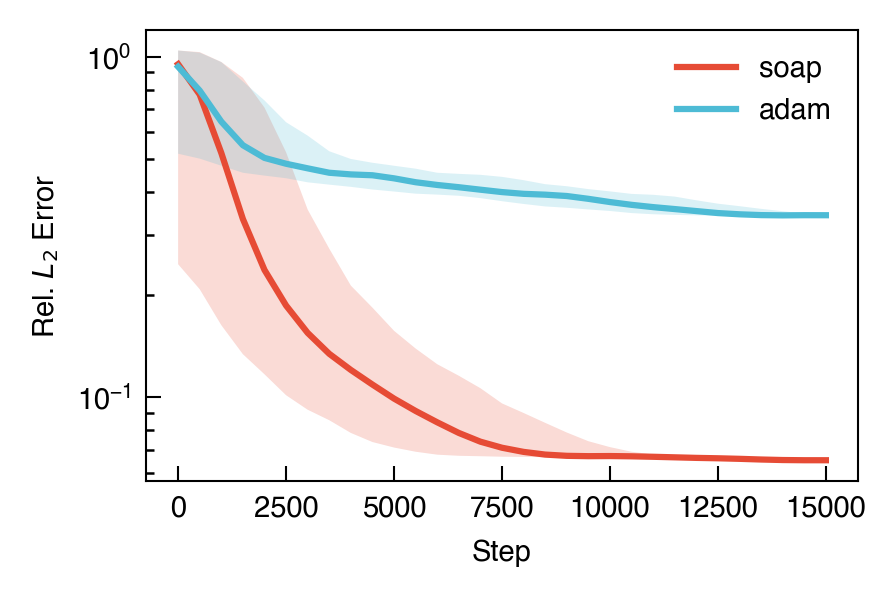

In [14]:
from models.utils import smooth_loss_log_gaussian
import pandas as pd

paths = [
    "training_logs/ldc/run-ldc_cvit_SOTA-0218-decdepth4-tag-eval_l2_error.csv",
    "training_logs/ldc/run-ldc_cvit_ablation_adam-tag-eval_l2_error.csv"
]

tags = ["soap", "adam"]


final_step = 15000

fig, ax = plt.subplots(figsize=(3, 2))
for i, (path, tag) in enumerate(zip(paths, tags)):
    df = pd.read_csv(path)
    df = df[df["Step"] <= final_step]
    val = df["Value"]
    step = df["Step"]
    # ax.plot(df["Step"], df["Value"], label=tag)
    mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.0, n_boot=1000)
    ax.plot(step, mean, label=tag)
    ax.fill_between(step, lower, upper, alpha=0.2)
ax.set(xlabel="Step", ylabel="Rel. $L_2$ Error", yscale="log")
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
from ldc.simplified_cvit import CViT
from ldc.simplified_deeponet import DeepONet
from models.fno import FNO2d

from ldc.configs.train_cvit import Config as cvit_configs
from ldc.configs.train_deeponet import Config as deeponet_configs
from ldc.configs.train_fno import Config as fno_configs

model_info = [
    {
        "name": "CViT",
        "model": CViT,
        "config": cvit_configs,
        "weight": "/root/autodl-tmp/tf-logs/ldc/cvit/SOTA-0218-decdepth4/model_epoch_15000.eqx"
    },
    {
        "name": "DeepONet",
        "model": DeepONet,
        "config": deeponet_configs,
        "weight": "/root/autodl-tmp/tf-logs/ldc/deeponet/baseline/model_epoch_20000.eqx",
    },
    {
        "name": "FNO",
        "model": FNO2d,
        "config": fno_configs,
        "weight": "/root/autodl-tmp/tf-logs/ldc/fno/soap/model_epoch_500.eqx",
    },
]

In [35]:
# Nx = configs.Nx
# Ny = configs.Ny
Nx = 256
Ny = 256
data = jnp.load(configs.data_dir + f"/ldc_solutions_Re50-1000_N{Nx}.npz")
X = data["X"]
Y = data["Y"]
coords = jnp.stack([
    X.reshape(-1),
    Y.reshape(-1)
], axis=-1)  # (Ny*Nx, 2)
target_reynold = data["Re"]
ref_data = data["data"] # (B, 2, Ny, Nx)
target_reynold = target_reynold.reshape(-1, 1)  # (B, 1)
target_reynold_normed = configs.normalize_re(target_reynold)

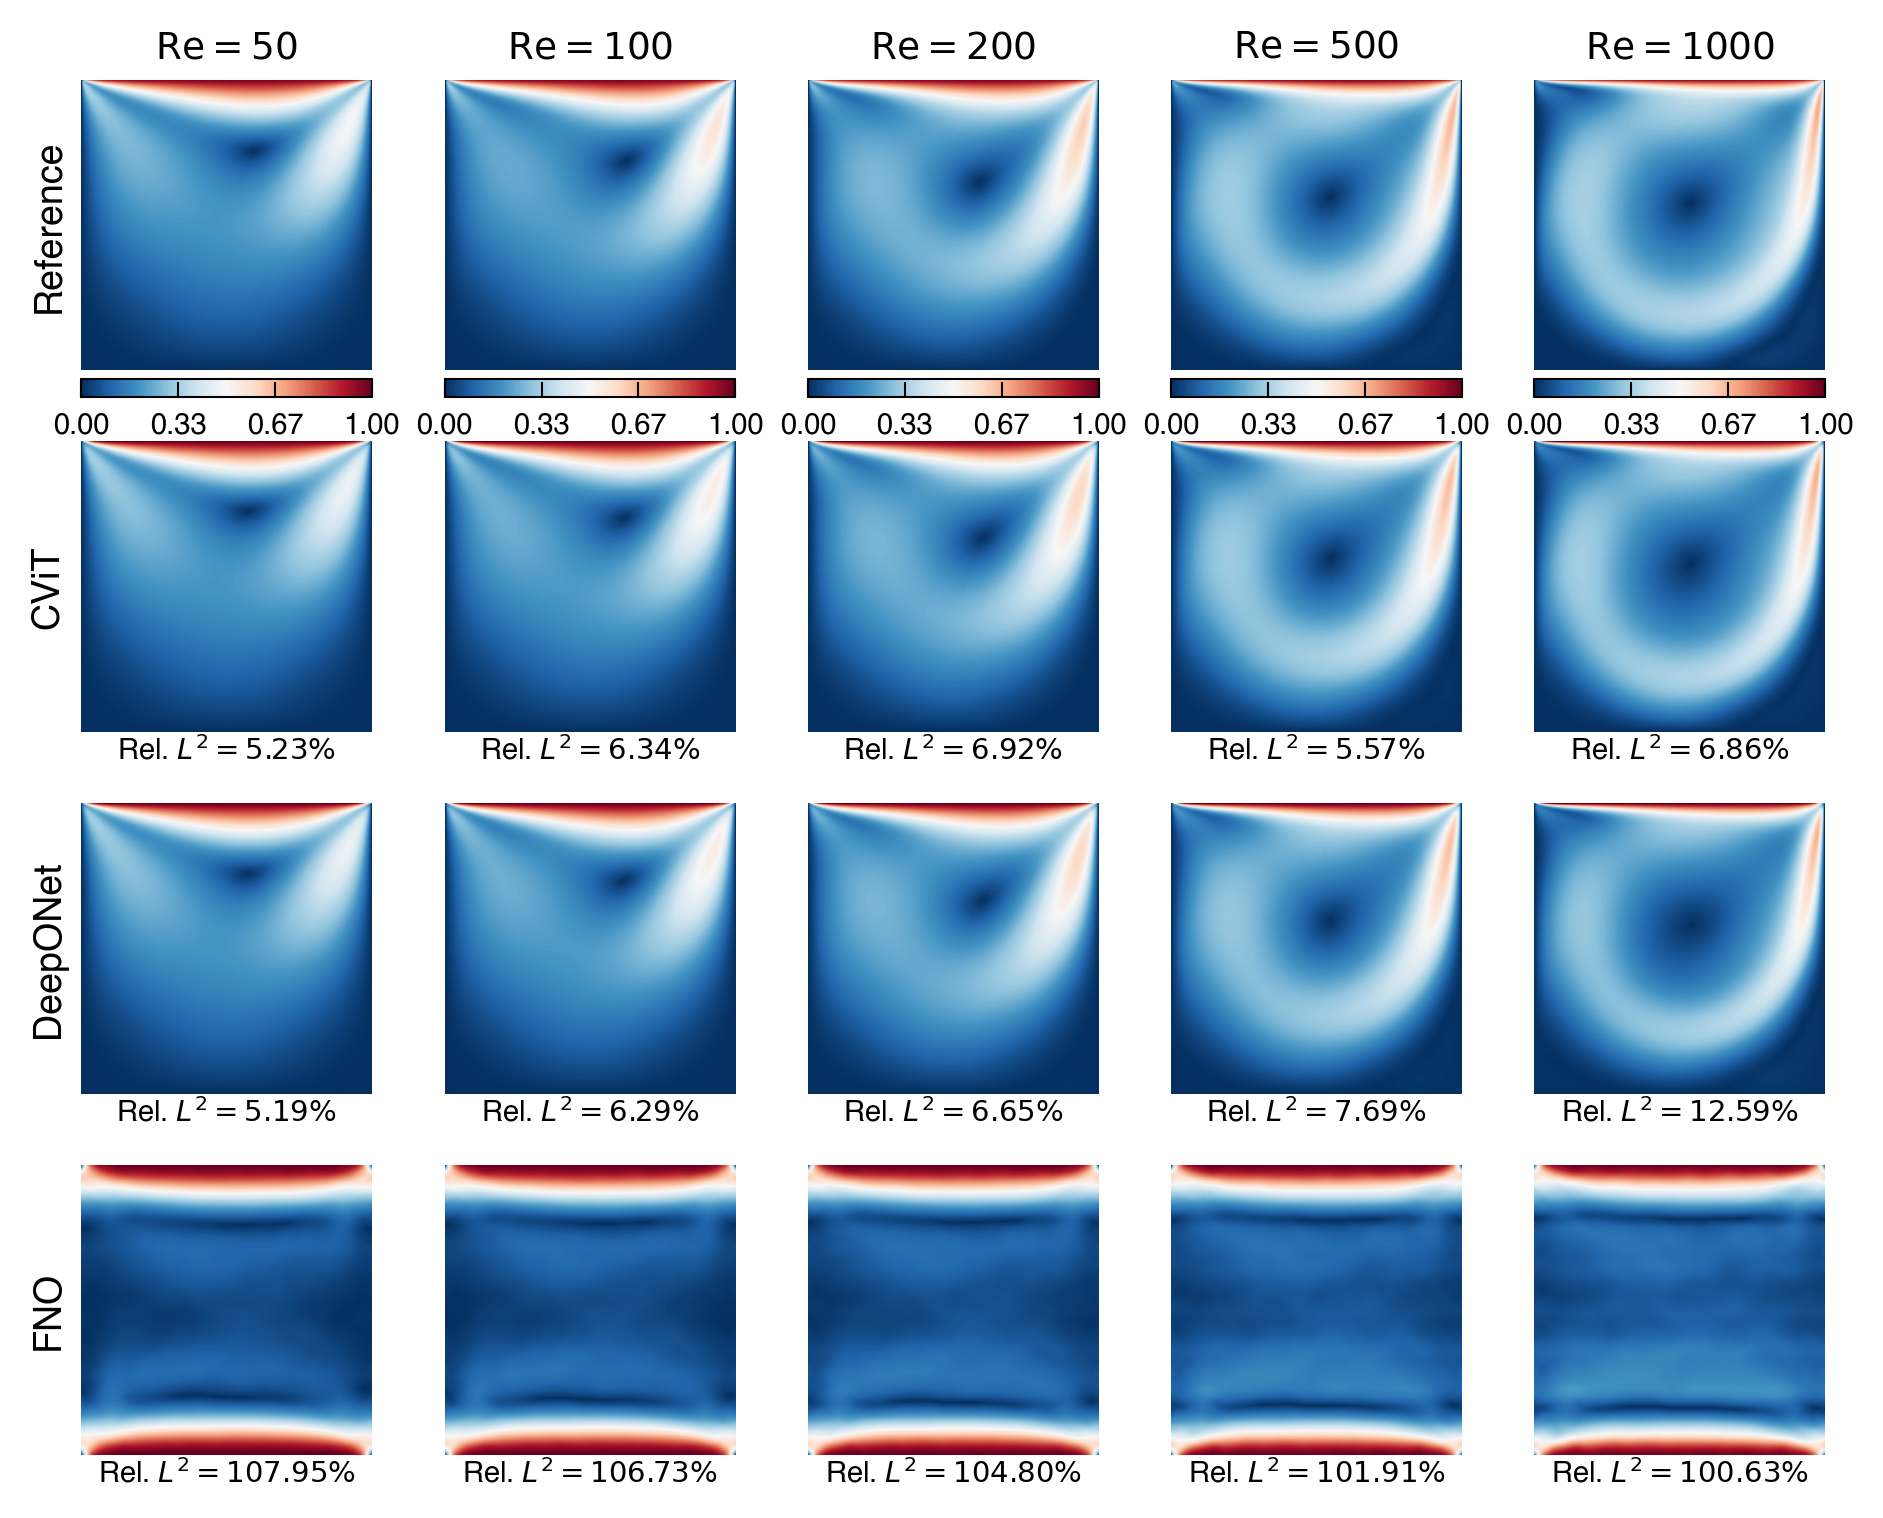

In [44]:
from matplotlib import gridspec
fig = plt.figure(figsize=(7.5, 6))
gs = gridspec.GridSpec(4, len(target_reynold), figure=fig, wspace=0.25, hspace=0.2, height_ratios=[1, 1, 1, 1])
ref_speed = jnp.sqrt(ref_data[:, 0, :, :]**2 + ref_data[:, 1, :, :]**2)
max_vals = jnp.max(ref_speed, axis=(1, 2)) # shape (B,)
min_vals = jnp.min(ref_speed, axis=(1, 2)) # shape (B,)
for col in range(len(target_reynold)):
    ax = fig.add_subplot(gs[0, col])
    ax.set_axis_off()
    this_reynold = target_reynold[col, 0]
    ax.text(
        0.5, 1.05, rf"$\mathrm{{Re}}={int(this_reynold)}$", 
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=9
    )
    ref_contourf = ax.imshow(
        ref_speed[col, :, :],
        cmap="RdBu_r",
        vmin=min_vals[col],
        vmax=max_vals[col],
        origin="lower",
        extent=(0, 1, 0, 1),
        rasterized=True,
        interpolation="bilinear"
    )
    if col == 0:
        ax.text(-0.05, 0.5, "Reference", rotation=90, va="center", ha="right", transform=ax.transAxes, fontsize=9)
        
    # add an extra ax to show colorbar for reference solution
    current_position = ax.get_position()
    cax = fig.add_axes([
        current_position.x0,
        current_position.y0 - 0.015,
        current_position.width,
        0.01,
    ])
    norm = plt.Normalize(vmin=min_vals[col], vmax=max_vals[col])
    sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", format="%.2f", 
                        ticks=jnp.linspace(min_vals[col], max_vals[col], num=4))
    
for row, info in enumerate(model_info):
    model_cls = info["model"]
    config_cls = info["config"]
    weight_path = info["weight"]
    name = info["name"]
    key = jax.random.PRNGKey(0)
    model_skeleton = model_cls(
        key,
        **config_cls.model_params,
    )
    
    model = eqx.tree_deserialise_leaves(weight_path, model_skeleton)
    
    if name.lower() == "fno":
        u0_fno = jnp.broadcast_to(target_reynold_normed[:, None, None],
                                  (target_reynold_normed.shape[0], 1, Nx, Ny))
        pred = jax.vmap(model)(u0_fno)  # (B, 3, Nx, Ny)
        pred = jnp.swapaxes(pred, 2, 3)  # (B, 3, Ny, Nx)
        sols = pred[:, :2, :, :]
    else:
        sols = jax.vmap(
            model, in_axes=(0, None)
        )(target_reynold_normed, coords)  # (B, Ny*Nx, 3)
        B, _, C = sols.shape
        H = Ny
        W = Nx
        sols = rearrange(sols, "B (H W) C -> B C H W", H=int(H), W=int(W))  # (B, 3, H, W)
        sols = sols[:, :2, ...]
        
    pred_speed = jnp.sqrt(sols[:, 0, :, :]**2 + sols[:, 1, :, :]**2)
    
    for col in range(len(target_reynold)):
        ax = fig.add_subplot(gs[row+1, col])
        ax.set_axis_off()
        this_reynold = target_reynold[col, 0]
        pred_contourf = ax.imshow(
            pred_speed[col, :, :],
            cmap="RdBu_r",
            vmin=min_vals[col],
            vmax=max_vals[col],
            origin="lower",
            extent=(0, 1, 0, 1),
            rasterized=True,
            interpolation="bilinear"
        )
        
        l2_error = jnp.linalg.norm(pred_speed[col, :, :] - ref_speed[col, :, :]) / jnp.linalg.norm(ref_speed[col, :, :])
        l2_error_percent = l2_error * 100
        
        ax.text(0.5, -0.01, fr"Rel. $L^2 = {l2_error_percent:.2f}\%$", va="top", ha="center", transform=ax.transAxes)
        
        if col == 0:
            ax.text(-0.05, 0.5, name, rotation=90, va="center", ha="right", transform=ax.transAxes, fontsize=9)
            
fig.savefig("./figures/ldc_solution_all_models.pdf", dpi=300, bbox_inches="tight", pad_inches=0.01)



In [ ]:

# 
# sols = jax.vmap(
#     model, in_axes=(0, None)
# )(target_reynold_normed, coords)  # (B, Ny*Nx, 3)

# B, _, C = sols.shape
# H = Ny
# W = Nx
# sols = rearrange(sols, "B (H W) C -> B C H W", H=int(H), W=int(W))  # (B, 3, H, W)
# sols = sols[:, :2, ...]
# # mask 左上和右上角的奇点，把u, v, speed对应位置设为0
# eps = 1e-2
# mask = (X > 1 - eps) & (Y > 1 - eps) | (X < eps) & (Y > 1 - eps)
# # sols = jnp.where(mask[None, None, :, :], 0.0, sols)
# # ref_data = jnp.where(mask[None, None, :, :], 0.0, ref_data)
# l2 = jnp.sqrt(jnp.mean((sols - ref_data)**2, axis=(-1, -2))) / jnp.sqrt(jnp.mean(ref_data**2, axis=(-1, -2)))
# l2 = jnp.mean(l2)
# print("L2 relative error:", l2)

L2 relative error: 0.06854373
